# pltx Showcase Notebook

A comprehensive walkthrough of all `pltx` features, translated from `examples/showcase.py`.

> **Sections**
> 1. Setup & style initialisation
> 2. Line outlines for better visibility
> 3. Centreines & hybrid enhancements
> 4. Color intensity variations
> 5. Reference lines & highlighted regions
> 6. Log scale with color cycling
> 7. Accessibility – progressive line widths
> 8. Styled bar charts
> 9. Styled histograms
> 10. Error bars
> 11. Markers with outlines
> 12. **Pasqal colormap** (from `cmap/`)

## 1 · Setup

In [2]:
import sys
import os

# Make sure we can import pltx from the repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as mpl_plt
import pltx.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Common data used throughout the notebook
x  = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.exp(-0.1 * x)
noise = 0.1 * np.random.randn(len(x))

# Initialise global style
plt.initialize_style(
    palette_name='plasma_r',
    palette_size=10,
    font_size_medium=11,
    font_size_large=13,
    use_tex=False,
)
print('pltx ready ✓')

pltx ready ✓


## 2 · Line Outlines for Better Visibility

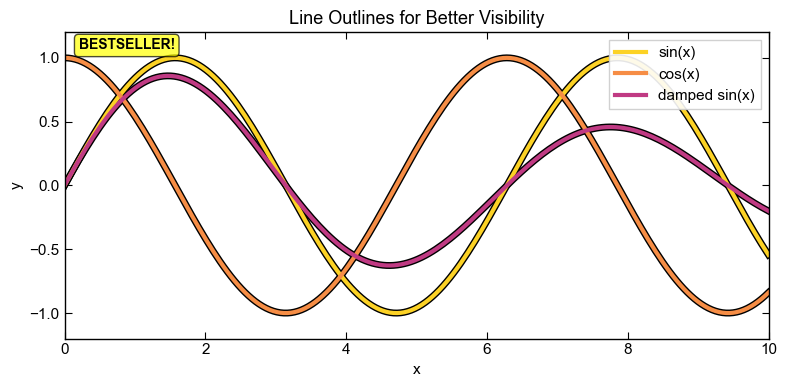

In [3]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1, color_idx=0, linewidth=3, label='sin(x)',
                outline=True, outline_width=5, ax=ax)
plt.plot_styled(x, y2, color_idx=2, linewidth=3, label='cos(x)',
                outline=True, outline_width=5, ax=ax)
plt.plot_styled(x, y3, color_idx=5, linewidth=3, label='damped sin(x)',
                outline=True, outline_width=5, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Line Outlines for Better Visibility',
               grid=False, xlim=(0, 10), ylim=(-1.2, 1.2))
ax.legend(loc='upper right', framealpha=0.9)
ax.text(0.02, 0.98, 'BESTSELLER!', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
mpl_plt.tight_layout()
mpl_plt.show()

## 3 · Centrelines & Hybrid Enhancements

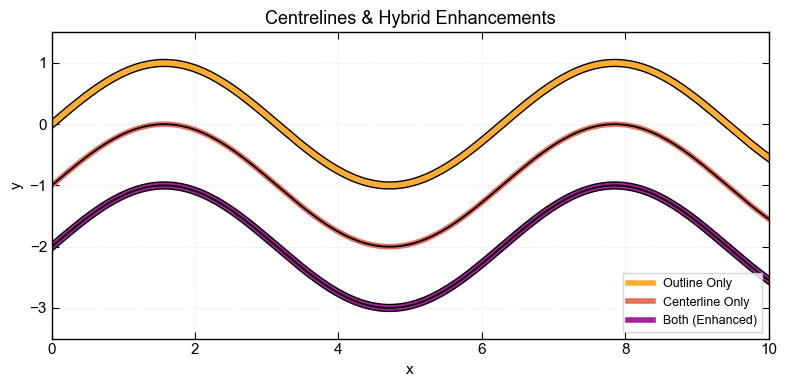

In [4]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1,     color_idx=1, linewidth=4, label='Outline Only',
                outline=True, ax=ax)
plt.plot_styled(x, y1 - 1, color_idx=3, linewidth=4, label='Centerline Only',
                centerline=True, ax=ax)
plt.plot_styled(x, y1 - 2, color_idx=6, linewidth=4, label='Both (Enhanced)',
                outline=True, centerline=True, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Centrelines & Hybrid Enhancements',
               grid=True, xlim=(0, 10), ylim=(-3.5, 1.5))
ax.legend(loc='lower right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 4 · Color Intensity Variations

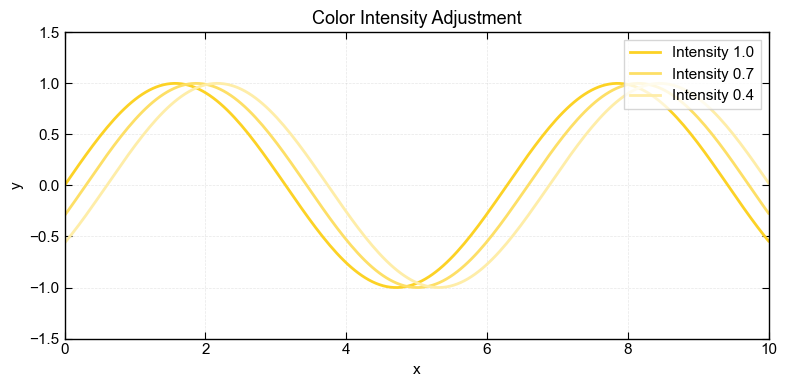

In [5]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

for i, intensity in enumerate([1.0, 0.7, 0.4]):
    plt.plot_styled(x, np.sin(x - i * 0.3),
                    color_idx=0, color_intensity=intensity,
                    linewidth=2, label=f'Intensity {intensity}', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Color Intensity Adjustment',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right')
mpl_plt.tight_layout()
mpl_plt.show()

## 5 · Reference Lines & Highlighted Regions

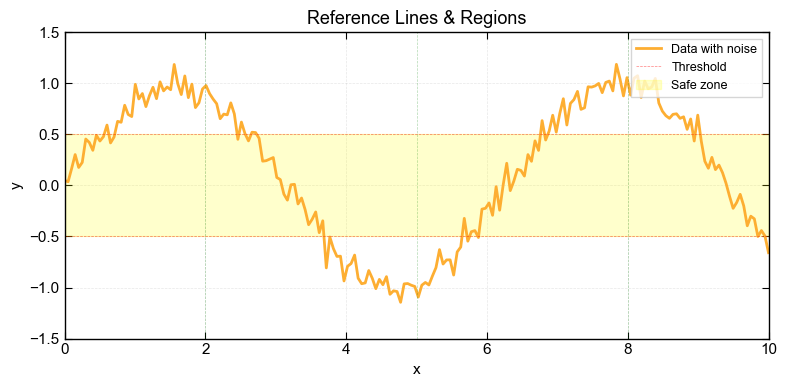

In [6]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

plt.plot_styled(x, y1 + noise, color_idx=1, linewidth=2,
               label='Data with noise', ax=ax)
plt.add_reference_line(horizontal=[0.5, -0.5], color='red',
                       linestyle='--', alpha=0.5, label='Threshold', ax=ax)
plt.add_reference_line(vertical=[2, 5, 8], color='green', alpha=0.3, ax=ax)
plt.add_highlight_region(ymin=-0.5, ymax=0.5, color='yellow',
                         alpha=0.2, label='Safe zone', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Reference Lines & Regions',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 6 · Log Scale with Auto Color Cycling

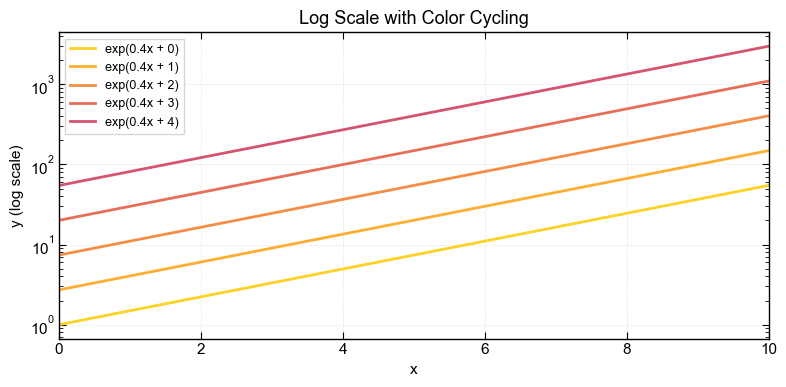

In [7]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

for i in range(5):
    plt.plot_styled(x, np.exp(0.4 * x + i), color_idx=i,
                    linewidth=2, label=f'exp(0.4x + {i})', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y (log scale)',
               title='Log Scale with Color Cycling',
               yscale='log', grid=True, xlim=(0, 10))
ax.legend(loc='upper left', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 7 · Accessibility – Progressive Line Widths

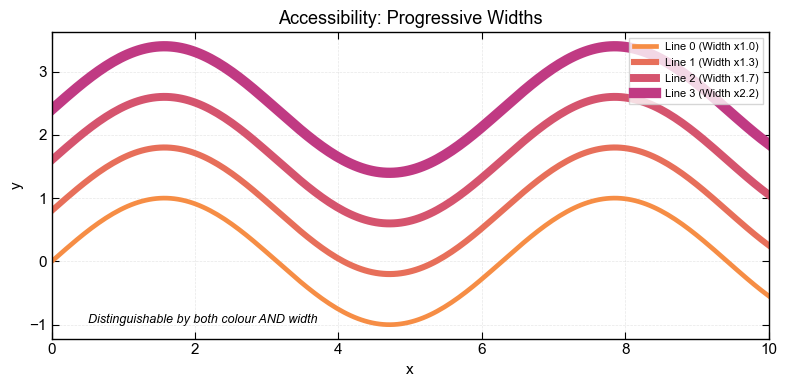

In [8]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

with plt.style_context('default', vary_linewidth=True):
    for i in range(4):
        plt.plot_styled(x, np.sin(x) + i * 0.8, color_idx=i + 2,
                        label=f'Line {i} (Width x{1.3**i:.1f})', ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Accessibility: Progressive Widths',
               grid=True, xlim=(0, 10))
ax.legend(loc='upper right', fontsize=8)
ax.text(0.05, 0.05, 'Distinguishable by both colour AND width',
        transform=ax.transAxes, fontsize=9, style='italic')
mpl_plt.tight_layout()
mpl_plt.show()

## 8 · Styled Bar Charts

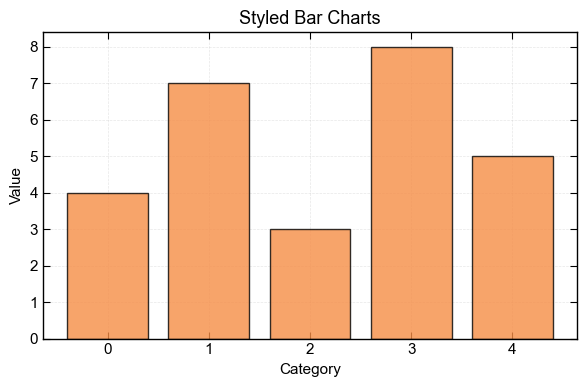

In [9]:
fig, ax = mpl_plt.subplots(figsize=(6, 4))

plt.bar_styled(['A', 'B', 'C', 'D', 'E'], [4, 7, 3, 8, 5],
               color_idx=2, alpha=0.8, ax=ax)
plt.setup_axis(ax, xlabel='Category', ylabel='Value',
               title='Styled Bar Charts', grid=True)
mpl_plt.tight_layout()
mpl_plt.show()

## 9 · Styled Histograms

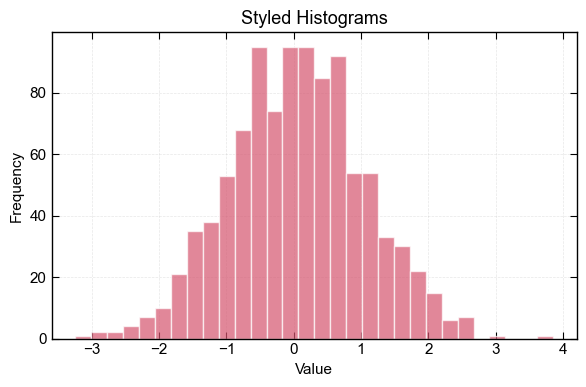

In [10]:
fig, ax = mpl_plt.subplots(figsize=(6, 4))

data = np.random.normal(0, 1, 1000)
plt.hist_styled(data, bins=30, color_idx=4, alpha=0.7,
               edgecolor='white', ax=ax)
plt.setup_axis(ax, xlabel='Value', ylabel='Frequency',
               title='Styled Histograms', grid=True)
mpl_plt.tight_layout()
mpl_plt.show()

## 10 · Error Bars

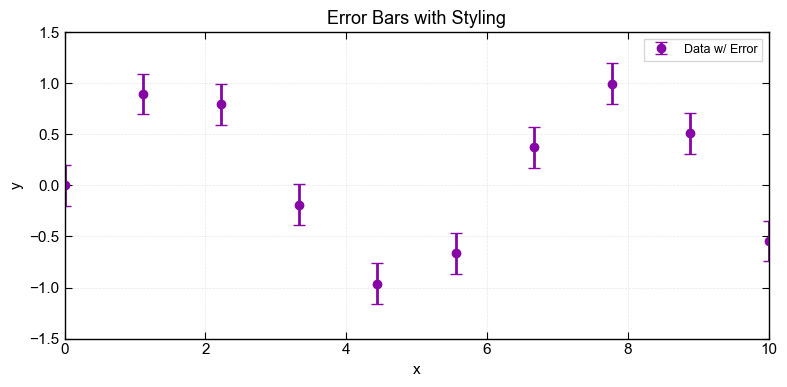

In [11]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

x_err = np.linspace(0, 10, 10)
y_err = np.sin(x_err)
err   = 0.2 * np.ones_like(x_err)

plt.errorbar_styled(x_err, y_err, yerr=err, color_idx=7,
                    linewidth=2, capsize=4, label='Data w/ Error', ax=ax)
plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Error Bars with Styling',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 11 · Markers with Outlines

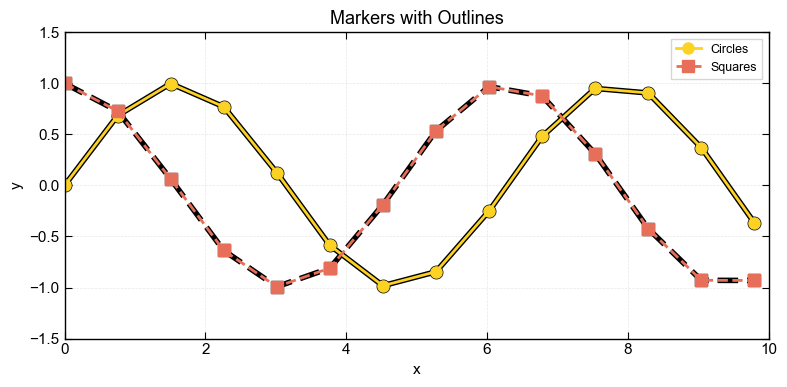

In [12]:
fig, ax = mpl_plt.subplots(figsize=(8, 4))

x_sparse = x[::15]
plt.plot_styled(x_sparse, np.sin(x_sparse), color_idx=0,
               marker='o', markersize=8, linestyle='-', linewidth=2,
               label='Circles', outline=True, ax=ax)
plt.plot_styled(x_sparse, np.cos(x_sparse), color_idx=3,
               marker='s', markersize=8, linestyle='--', linewidth=2,
               label='Squares', outline=True, ax=ax)

plt.setup_axis(ax, xlabel='x', ylabel='y',
               title='Markers with Outlines',
               grid=True, xlim=(0, 10), ylim=(-1.5, 1.5))
ax.legend(loc='upper right', fontsize=9)
mpl_plt.tight_layout()
mpl_plt.show()

## 12 · Pasqal Custom Colormap (`cmap/`)

The `cmap/` directory ships two `.npy` files with hand-crafted Pasqal colour maps:
- `pasqal_cmap.npy` — main Pasqal brand colourmap
- `pasqal_contrast_cmap.npy` — higher-contrast variant

Below we register both as proper `matplotlib` colourmaps and demonstrate them on a 2-D heatmap.

In [13]:
from matplotlib.colors import LinearSegmentedColormap

# ── Load the .npy colour tables ───────────────────────────────────────────────
cmap_dir = os.path.join(REPO_ROOT, 'cmap')

pasqal_colors          = np.load(os.path.join(cmap_dir, 'pasqal_cmap.npy'))
pasqal_contrast_colors = np.load(os.path.join(cmap_dir, 'pasqal_contrast_cmap.npy'))

# Register as named matplotlib colormaps (safe to run multiple times)
for name, colors in [
    ('pasqal',          pasqal_colors),
    ('pasqal_contrast', pasqal_contrast_colors),
]:
    cmap = LinearSegmentedColormap.from_list(name, colors)
    mpl_plt.colormaps.register(cmap, name=name, force=True)

print(f'pasqal_cmap          shape: {pasqal_colors.shape}')
print(f'pasqal_contrast_cmap shape: {pasqal_contrast_colors.shape}')
print('Colormaps registered ✓')

pasqal_cmap          shape: (256, 3)
pasqal_contrast_cmap shape: (256, 3)
Colormaps registered ✓


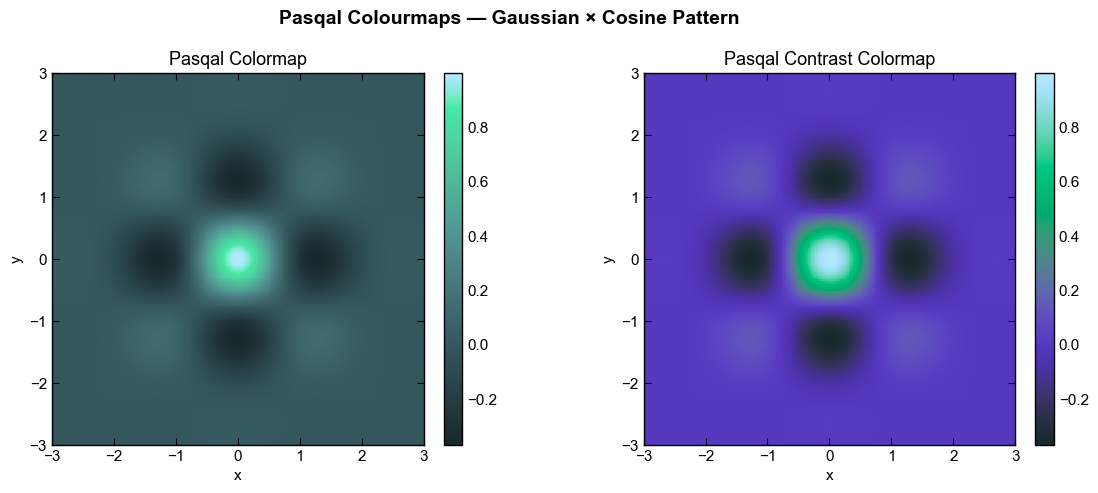

In [14]:
# ── Demo data: 2-D Gaussian + sine modulation ─────────────────────────────────
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = np.exp(-(grid_x**2 + grid_y**2) / 2) * np.cos(2 * grid_x) * np.cos(2 * grid_y)

fig, axes = mpl_plt.subplots(1, 2, figsize=(12, 5))

for ax, cmap_name, title in zip(
    axes,
    ['pasqal', 'pasqal_contrast'],
    ['Pasqal Colormap', 'Pasqal Contrast Colormap'],
):
    im = ax.imshow(Z, cmap=cmap_name, origin='lower',
                   extent=[-3, 3, -3, 3], aspect='equal')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.setup_axis(ax, xlabel='x', ylabel='y', title=title)

fig.suptitle('Pasqal Colourmaps — Gaussian × Cosine Pattern',
             fontsize=14, fontweight='bold')
mpl_plt.tight_layout()
mpl_plt.show()

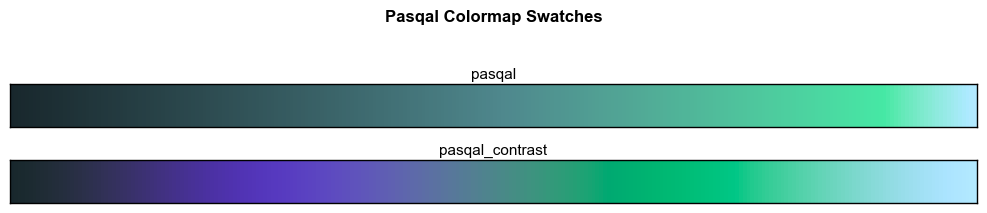

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.proce

In [ ]:
# ── Colormap swatch ───────────────────────────────────────────────────────────
fig, axes = mpl_plt.subplots(2, 1, figsize=(10, 2))

for ax, name in zip(axes, ['pasqal', 'pasqal_contrast']):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=name)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(name, fontsize=11, pad=4)

mpl_plt.suptitle('Pasqal Colormap Swatches', fontsize=12, fontweight='bold', y=1.05)
mpl_plt.tight_layout()
mpl_plt.show()

### 12b · Pasqal Colourmaps on Sine & Cosine Plots

A colourmap doesn't have to stay on 2-D images.
Here we sample **N evenly-spaced colours** from the registered Pasqal colourmaps and use them to colour a family of **phase-shifted sine and cosine curves**.
This lets you see the full gradient in a line-plot context — and highlights how the two maps differ in perceptual contrast.

Key steps:
1. Sample `N` colours from the colormap using `mpl_plt.get_cmap(name)(i / (N-1))`.
2. Plot `sin(x + φᵢ)` and `cos(x + φᵢ)` for each phase φᵢ, coloured accordingly.
3. Add a `ScalarMappable` colorbar so the viewer can read off which phase corresponds to which colour.

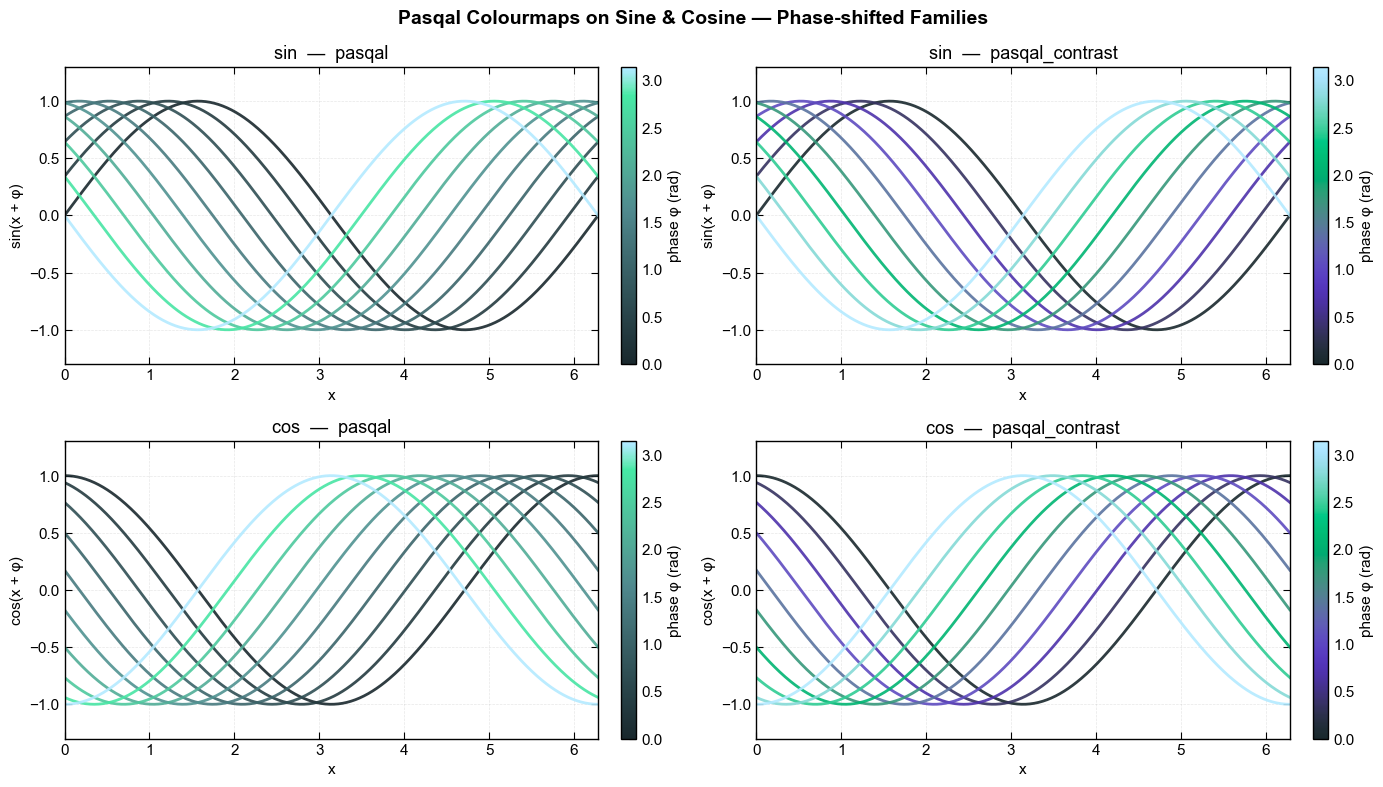

Tip: use  mpl_plt.get_cmap('pasqal')(t)  for any t ∈ [0, 1] to pick a colour.


Bad pipe message: %s [b"\x99\xea7\x9bu\xc6d\xd5\xb0\xd4\xf3\xf1\xc0\xa6\xbe\xa8\x0f2 \xb4\xd7?F\x94\xbe\xc8\xfd\xe2\x9e\xefr\xca\xe5\xfd)\xc5\xfbm\x1e0o\xa3\xb1\x13n3/2\xe6X>\x00$\x13\x01\x13\x02\x13\x03\xc0/\xc0+\xc00\xc0,\xc0'\xcc\xa9\xcc\xa8\xc0\t\xc0\x13\xc0\n\xc0\x14\x00\x9c\x00\x9d\x00/\x005\x01\x00\x00p\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x08\x00\x06\x00\x1d\x00\x17\x00\x18\x00\x0b\x00\x02\x01\x00\x00#\x00\x00\x00\r\x00\x14\x00\x12\x04\x03\x08\x04\x04\x01\x05\x03\x08\x05\x05\x01\x08\x06\x06\x01\x02\x01\x003\x00&\x00$\x00\x1d\x00 \xfa\xcb\x80\x99\x7f5\x05s\xd0\x1f\xd5n\x12\x8eU\x8c\x02\xce\xf4\xd5\x99:\xda\xe5\xd7\xd5e\x0b\xc4 0c\x00-\x00\x02\x01\x01"]
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/i.sokolov/Code/pltx/.venv/lib/python3.10/site-packages/ipykernel/kernelb

In [ ]:
# ── Pasqal colourmaps on sine & cosine plots ──────────────────────────────────
import matplotlib.cm as mpl_cm
from matplotlib.colors import Normalize

N_CURVES = 10        # number of phase-shifted curves
x_line   = np.linspace(0, 2 * np.pi, 500)
phases   = np.linspace(0, np.pi, N_CURVES)   # φ ∈ [0, π]

fig, axes = mpl_plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Pasqal Colourmaps on Sine & Cosine — Phase-shifted Families",
    fontsize=14, fontweight="bold",
)

for col, cmap_name in enumerate(["pasqal", "pasqal_contrast"]):
    cmap_obj = mpl_plt.get_cmap(cmap_name)
    norm     = Normalize(vmin=0, vmax=np.pi)

    # ── row 0: sine ──────────────────────────────────────────────────────────
    ax_sin = axes[0, col]
    for i, phi in enumerate(phases):
        color = cmap_obj(i / (N_CURVES - 1))
        ax_sin.plot(x_line, np.sin(x_line + phi),
                    color=color, linewidth=2, alpha=0.9)
    fig.colorbar(
        mpl_cm.ScalarMappable(norm=norm, cmap=cmap_obj),
        ax=ax_sin, label="phase φ (rad)", fraction=0.046, pad=0.04,
    )
    plt.setup_axis(
        ax_sin,
        xlabel="x", ylabel="sin(x + φ)",
        title=f"sin  —  {cmap_name}",
        grid=True, xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
    )

    # ── row 1: cosine ────────────────────────────────────────────────────────
    ax_cos = axes[1, col]
    for i, phi in enumerate(phases):
        color = cmap_obj(i / (N_CURVES - 1))
        ax_cos.plot(x_line, np.cos(x_line + phi),
                    color=color, linewidth=2, alpha=0.9)
    fig.colorbar(
        mpl_cm.ScalarMappable(norm=norm, cmap=cmap_obj),
        ax=ax_cos, label="phase φ (rad)", fraction=0.046, pad=0.04,
    )
    plt.setup_axis(
        ax_cos,
        xlabel="x", ylabel="cos(x + φ)",
        title=f"cos  —  {cmap_name}",
        grid=True, xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
    )

mpl_plt.tight_layout()
mpl_plt.show()
print("Tip: use  mpl_plt.get_cmap('pasqal')(t)  for any t ∈ [0, 1] to pick a colour.")